# Exploratory Data Analysis For ECS #1 Data (Aug 2026)

This notebook will run through an Exploratory Data Analysis (EDA) of the Nortek Eddy Covariance #1 instrument I deployed in South Bay, VA in August 2026. This instrument was deployed in the middle of a seagrass meadow of Zostera marina. I plan to explore the size of the dataset, number of missing values, data types, calculating some descriptive statistics, looking for correlations, plotting the [O2] time series, as well as the directional velocity time series (m/s), etc.

I will be using a variety of different data files under the general names `E1081401` file in the zipped `DATA` folder of my repository. These files come in many different types and within them have many different types of data. The data that can be found in each file is outlined in the `E1081401.hdr` file. There are no headers within any of these files.

On this deployment we also tried to collect data from the HammerHead O2 Profiler that we built in the Bio-Optical Research Laboratory (BORG) at ODU. This instrument was placed right next to eddy covariance instrument #1 in the seagrass meadow, but the SD card corrupted. We also deployed eddy covariance instrument #2 at a bare sand site, but this instrument was knocked over within the first day of deployment. Will also look at this instrument to see how reasonable the data looks. That will be in a separate notebook though.

In [1]:
# Load in the packages I will use for analysis
# pandas, matplotlib, cartopy, seaborn, numpy 

import pandas as pd  # pandas is for data analysis and manipulation
import seaborn as sea  # seaborn is for data visualization
import matplotlib.pyplot as plt # matplotlib is the OG python plotting library and really useful for formatting 
import cartopy as crt  # cartopy is a package for geospatial data processing
import numpy as np  # numpy is for numerical computing

In [2]:
# Load in the .dat file for ECS #1

# Set the path to the correct directory
infile = 'C:/Users/jtgal/OEAS805_Project/DATA/EDDY/RAW_DATA/Eddy1/E1081401.dat'

# Read in the .dat file
data = pd.read_csv(infile, sep=",", header=None)

data = pd.read_csv(infile, sep=r"\s+", header=None)

# Print the shape of the data
print("Rows and Columns:", data.shape)

# Showing what data types are present
data.info()

Rows and Columns: (2205020, 18)
<class 'pandas.DataFrame'>
RangeIndex: 2205020 entries, 0 to 2205019
Data columns (total 18 columns):
 #   Column  Dtype  
---  ------  -----  
 0   0       int64  
 1   1       int64  
 2   2       float64
 3   3       float64
 4   4       float64
 5   5       int64  
 6   6       int64  
 7   7       int64  
 8   8       float64
 9   9       float64
 10  10      float64
 11  11      int64  
 12  12      int64  
 13  13      int64  
 14  14      float64
 15  15      int64  
 16  16      int64  
 17  17      int64  
dtypes: float64(7), int64(11)
memory usage: 302.8 MB


There 18 columns and 2,205,020 rows with each row symbolizing a sample of the data for each of the 18 variables.

This dataset was collected by eddy covariance instrument #1 that includes a Nortek Acoustic Doppler Velocimeter (ADV) and Firesting O2 optodes and IS my own primary data. It will have data about raw O2 concentrations, directional current velocities, and pressure to get depth from. Data was collected over a 3 day period. Sampling was happening at 16 Hz for 1 consecutive minute and then slept for 1 minute. Sampling started on 08/14/2026 @ 11:00:01 and ended on 08/17/2026 @ 10:56:29.

There is no spatial component to this dataset besides the known coordinate locations of these stations.

In [3]:
# Show the number of missing values in each column
display(data.isna().sum())

# Show the first few rows of the data
display(data.head())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
dtype: int64

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,1,1,-0.5414,0.0486,-0.0351,40,43,43,-1.3,-0.4,-0.4,8,8,19,0.014,174,0,0
1,1,2,0.5348,0.7477,-0.1242,41,44,43,-0.9,0.0,-0.4,9,7,9,0.011,174,0,0
2,1,3,-0.1123,0.1133,0.2014,40,44,43,-1.3,0.0,-0.4,8,2,2,0.009,173,0,0
3,1,4,0.4078,0.5087,0.0439,41,45,43,-0.9,0.4,-0.4,22,9,6,0.007,173,0,0
4,1,5,-0.2614,0.0233,-0.0106,41,45,45,-0.9,0.4,0.4,2,2,6,0.015,173,0,0


There are 0 missing values in the data. However, there is no header for all the columns so I need to assign some.

In [4]:
from pathlib import Path # This is required in order to use the same path, put pull a different type of file

# Bring in the .hdr to tell what all the files headers are and print it
hdrfile = Path(infile).with_suffix(".hdr")
print(hdrfile.read_text(encoding="utf-8", errors="replace"))

[C:\BORG_INSTRUMENTS\ECS_n1\E1081401.vec]
---------------------------------------------------------------------
Number of measurements                2205020
Number of velocity checksum errors    0
Number of sensor checksum errors      0
Number of data gaps                   1
Time of first measurement             2026-08-14 11:00:00
Time of last measurement              2026-08-17 15:32:50

User setup
---------------------------------------------------------------------
Sampling rate                         16 Hz
Nominal velocity range                0.30 m/s
Burst interval                        120 sec
Samples per burst                     960
Sampling volume                       14.9 mm
Measurement load                      59 %
Transmit length                       4.0 mm
Receive length                        0.01 m
Output sync                           VECTOR
Analog output                         DISABLED
Analog input 1                        FAST
Analog input 2                 

I will use the `___.hdr` file for this set of files to determine the variable for each column in the `___.dat` file.

It looks like the columns are:
 1   Burst counter,
 2   Ensemble counter                 (1-65536),
 3   Velocity (Beam1|X|East)          (m/s),
 4   Velocity (Beam2|Y|North)         (m/s),
 5   Velocity (Beam3|Z|Up)            (m/s),
 6   Amplitude (Beam1)                (counts),
 7   Amplitude (Beam2)                (counts),
 8   Amplitude (Beam3)                (counts),
 9   SNR (Beam1)                      (dB),
10   SNR (Beam2)                      (dB),
11   SNR (Beam3)                      (dB),
12   Correlation (Beam1)              (%),
13   Correlation (Beam2)              (%),
14   Correlation (Beam3)              (%),
15   Pressure                         (dbar),
16   Analog input 1,
17   Analog input 2,
18   Checksum                         (1=failed)

Column 16 (Analog Input 1) is where the O2 counts (1-65536) are stored. This signal comes from the Firesting O2 sensor input into the Nortek data collection.

In [5]:
# Define column names from the .hdr file for the .dat file
column_names = [
    "BurstCounter",
    "EnsembleCounter (1-65536)",
    "Velocity1 (X|East)(m/s)",
    "Velocity2 (Y|North)(m/s)",
    "Velocity3 (Z|Up)(m/s)",
    "Amplitude1 (Counts)",
    "Amplitude2 (Counts)",
    "Amplitude3 (Counts)",
    "SNR1 (dB)",
    "SNR2 (dB)",
    "SNR3 (dB)",
    "Correlation1 (%)",
    "Correlation2 (%)",
    "Correlation3 (%)",
    "Pressure (dbar)",
    "AnalogInput1",
    "AnalogInput2",
    "Checksum",
]

# Returning a more descriptive error message if <18 column headers are provided
if len(column_names) != data.shape[1]:
    raise ValueError(
        f"Expected {data.shape[1]} column names, got {len(column_names)}"
    )

# Displaying first few rows of data with new headers
data.columns = column_names
display(data.head())

,BurstCounter,EnsembleCounter (1-65536),Velocity1 (X|East)(m/s),Velocity2 (Y|North)(m/s),Velocity3 (Z|Up)(m/s),Amplitude1 (Counts),Amplitude2 (Counts),Amplitude3 (Counts),SNR1 (dB),SNR2 (dB),SNR3 (dB),Correlation1 (%),Correlation2 (%),Correlation3 (%),Pressure (dbar),AnalogInput1,AnalogInput2,Checksum
0,1,1,-0.5414,0.0486,-0.0351,40,43,43,-1.3,-0.4,-0.4,8,8,19,0.014,174,0,0
1,1,2,0.5348,0.7477,-0.1242,41,44,43,-0.9,0.0,-0.4,9,7,9,0.011,174,0,0
2,1,3,-0.1123,0.1133,0.2014,40,44,43,-1.3,0.0,-0.4,8,2,2,0.009,173,0,0
3,1,4,0.4078,0.5087,0.0439,41,45,43,-0.9,0.4,-0.4,22,9,6,0.007,173,0,0
4,1,5,-0.2614,0.0233,-0.0106,41,45,45,-0.9,0.4,0.4,2,2,6,0.015,173,0,0


Column headers have no been added to their appropriate column.

In [6]:
# Show the info on the data again with new column headers
data.info()

# Show a summary of the data with calculated statistics (Inc. count, mean, std, etc.)
display(data.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 2205020 entries, 0 to 2205019
Data columns (total 18 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   BurstCounter               int64  
 1   EnsembleCounter (1-65536)  int64  
 2   Velocity1 (X|East)(m/s)    float64
 3   Velocity2 (Y|North)(m/s)   float64
 4   Velocity3 (Z|Up)(m/s)      float64
 5   Amplitude1 (Counts)        int64  
 6   Amplitude2 (Counts)        int64  
 7   Amplitude3 (Counts)        int64  
 8   SNR1 (dB)                  float64
 9   SNR2 (dB)                  float64
 10  SNR3 (dB)                  float64
 11  Correlation1 (%)           int64  
 12  Correlation2 (%)           int64  
 13  Correlation3 (%)           int64  
 14  Pressure (dbar)            float64
 15  AnalogInput1               int64  
 16  AnalogInput2               int64  
 17  Checksum                   int64  
dtypes: float64(7), int64(11)
memory usage: 302.8 MB


,count,mean,std,min,25%,50%,75%,max
BurstCounter,2205020.0,1148.947937,663.056837,1.0000,575.0000,1149.0000,1723.0000,2297.0000
EnsembleCounter (1-65536),2205020.0,480.483492,277.123162,1.0000,240.0000,480.0000,720.0000,960.0000
Velocity1 (X|East)(m/s),2205020.0,0.002949,0.122347,-1.2168,-0.0335,0.0009,0.0402,1.2645
Velocity2 (Y|North)(m/s),2205020.0,0.010286,0.143481,-1.2668,-0.0664,0.0104,0.0895,1.2382
Velocity3 (Z|Up)(m/s),2205020.0,-0.008295,0.051189,-0.9503,-0.0228,-0.0075,0.0053,0.9216
Amplitude1 (Counts),2205020.0,100.867561,18.771782,36.0000,97.0000,103.0000,109.0000,209.0000
Amplitude2 (Counts),2205020.0,105.890649,18.020005,40.0000,104.0000,109.0000,114.0000,215.0000
Amplitude3 (Counts),2205020.0,100.243279,17.233330,40.0000,97.0000,103.0000,109.0000,210.0000
SNR1 (dB),2205020.0,24.672946,8.042375,-3.4000,23.2000,25.8000,28.4000,71.4000
SNR2 (dB),2205020.0,26.677144,7.712277,-1.7000,25.8000,27.9000,30.1000,73.5000


Again, each column is now labeled with header name.

This Gives Averages Of:
    Analog Input 1 (O2 Counts) = 15453,
    East Velocity (m/s) = 0.002949,
    North Velocity (m/s) = 0.010286,
    Upward Velocity (m/s) = -0.008295,
    Pressure (dbar) = 0.765250

Other Important Values:
    Lower Quartile Analog Input 1 (O2 Counts) = 13602,
    Upper Quartile Analog Input 1 (O2 Counts) = 18097

This also shows through the range of 0-960 how the Ensemble Counter works to keep each set of 1 minute samples together.

In [7]:
sampling_rate = 16 # samples per second
burst_col = "BurstCounter" # column name tracking each burst

samples_per_burst = data.groupby(burst_col).size().sort_index() # sorts by the burst counter, establishing size, and indexing

active_seconds = len(data) / sampling_rate # calculates the total time spent sampling (Total rows / Samples per second)

first_burst = int(samples_per_burst.index[0]) # ID of first burst
last_burst = int(samples_per_burst.index[-1]) # ID of last burst
last_burst_samples = samples_per_burst.iloc[-1] # number of samples in the last burst

# Assumes each burst counter step represents a 1-minute burst
# followed by a 1-minute pause
elapsed_seconds = (
    (last_burst - first_burst) * 120 # calculates full 2 minute intervals of sampling time
    + last_burst_samples / sampling_rate # add a correction for the last burst
)

# printing the results
print("Active Sampling:", pd.to_timedelta(active_seconds, unit="s")) # pd.to_timedelta converts raw seconds to a time that can be read easily
print("Estimated Elapsed Time:", pd.to_timedelta(elapsed_seconds, unit="s"))
print("Number of Observed Bursts:", len(samples_per_burst))
print("Samples in the Last Burst:", last_burst_samples)

Active Sampling: 1 days 14:16:53.750000
Estimated Elapsed Time: 3 days 04:32:53.750000
Number of Observed Bursts: 2297
Samples in the Last Burst: 860


Taking what is known about the sampling speed (16 Hz) and sampling interval (1 minute ON, 1 minute OFF) I calculated the estimated elapsed time for the whole dataset. This calculated value gave 3 days, 4 hours, 32 minutes, and 53.75 seconds of total sampling which makes sense, although all this time will not be useable because the instrument was still sampling when we were transporting it back to the warehouse. We should be able to see this in the plots though.

In [8]:
sampling_rate = 16
cycle_seconds = 120  # 60 seconds sampling + 60 seconds pause

burst = data["BurstCounter"].astype("int64")
ensemble = data["EnsembleCounter (1-65536)"].astype("int64")

# Check that ensemble values represent samples 1 through 960.
if not ensemble.between(1, 960).all():
    raise ValueError("Ensemble counter contains values outside 1–960.")

start = pd.Timestamp("2026-08-14 11:00:01.0000")

# Offset each row from the first sample, including the pause between bursts.
offset_ns = (
    (burst - burst.min()) * cycle_seconds * 1_000_000_000
    + (ensemble - 1) * 1_000_000_000 // sampling_rate
)

data["Timestamp"] = start + pd.to_timedelta(offset_ns, unit="ns")
data["DateStamp"] = data["Timestamp"].dt.strftime("%Y-%m-%d")

display(data[["BurstCounter", "EnsembleCounter (1-65536)", "Timestamp", "DateStamp"]].head())
display(data[["Timestamp", "DateStamp"]].tail())

,BurstCounter,EnsembleCounter (1-65536),Timestamp,DateStamp
0,1,1,2026-08-14 11:00:01.000000,2026-08-14
1,1,2,2026-08-14 11:00:01.062500,2026-08-14
2,1,3,2026-08-14 11:00:01.125000,2026-08-14
3,1,4,2026-08-14 11:00:01.187500,2026-08-14
4,1,5,2026-08-14 11:00:01.250000,2026-08-14


,Timestamp,DateStamp
2205015,2026-08-17 15:32:59.125000,2026-08-17
2205016,2026-08-17 15:32:59.187500,2026-08-17
2205017,2026-08-17 15:32:59.250000,2026-08-17
2205018,2026-08-17 15:32:59.312500,2026-08-17
2205019,2026-08-17 15:32:59.375000,2026-08-17


Since there are only counters as the only way of keeping time I created an array with time based on the sampling rate/interval and known start times given by the instrument. The Timestamp column is in appropriate standard international date and time format of YYYY-MM-DD hh:mm:ss.

In [9]:
data = data[
    ["Timestamp", "DateStamp"]
    + [col for col in data.columns if col not in ("Timestamp", "DateStamp")]
]

# Displaying first few rows of data with new Timestamp and DateSta
display(data.head())

,Timestamp,DateStamp,BurstCounter,EnsembleCounter (1-65536),Velocity1 (X|East)(m/s),Velocity2 (Y|North)(m/s),Velocity3 (Z|Up)(m/s),Amplitude1 (Counts),Amplitude2 (Counts),Amplitude3 (Counts),SNR1 (dB),SNR2 (dB),SNR3 (dB),Correlation1 (%),Correlation2 (%),Correlation3 (%),Pressure (dbar),AnalogInput1,AnalogInput2,Checksum
0,2026-08-14 11:00:01.000000,2026-08-14,1,1,-0.5414,0.0486,-0.0351,40,43,43,-1.3,-0.4,-0.4,8,8,19,0.014,174,0,0
1,2026-08-14 11:00:01.062500,2026-08-14,1,2,0.5348,0.7477,-0.1242,41,44,43,-0.9,0.0,-0.4,9,7,9,0.011,174,0,0
2,2026-08-14 11:00:01.125000,2026-08-14,1,3,-0.1123,0.1133,0.2014,40,44,43,-1.3,0.0,-0.4,8,2,2,0.009,173,0,0
3,2026-08-14 11:00:01.187500,2026-08-14,1,4,0.4078,0.5087,0.0439,41,45,43,-0.9,0.4,-0.4,22,9,6,0.007,173,0,0
4,2026-08-14 11:00:01.250000,2026-08-14,1,5,-0.2614,0.0233,-0.0106,41,45,45,-0.9,0.4,0.4,2,2,6,0.015,173,0,0


I attached this new Timestamp and Datestamp columns at the beginning of the array so they are linked with the original data I called in.

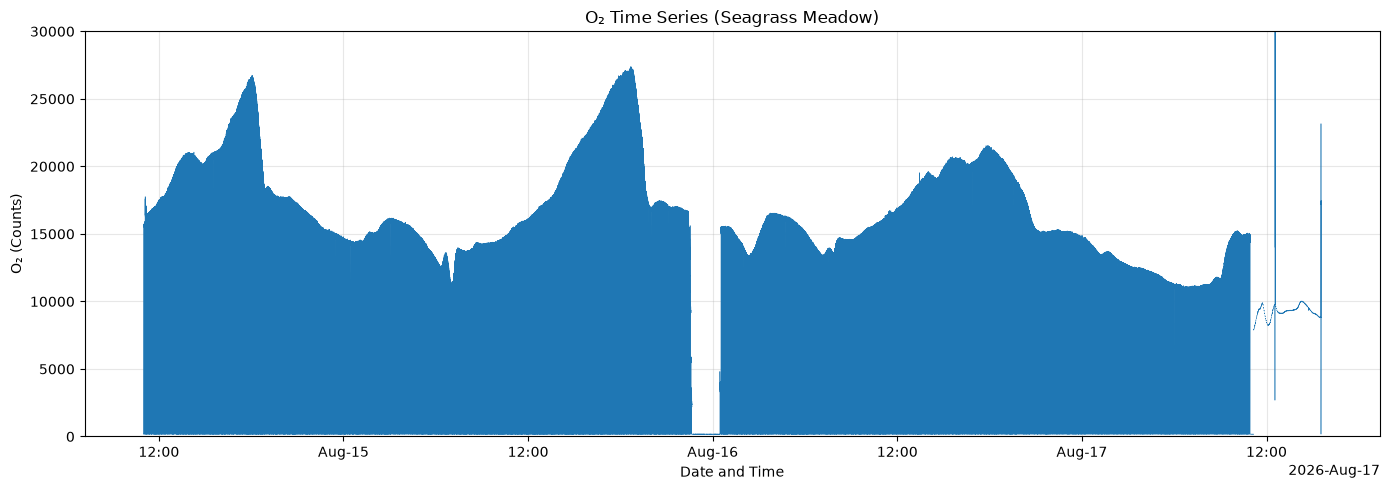

In [69]:
import matplotlib.dates as mdates
from pathlib import Path

plot_data = data[["Timestamp", "BurstCounter", "AnalogInput1"]].copy()
plot_data["Timestamp"] = pd.to_datetime(plot_data["Timestamp"])
plot_data["O2"] = pd.to_numeric(plot_data["AnalogInput1"], errors="coerce")
plot_data = plot_data.dropna(subset=["Timestamp", "O2"]).sort_values("Timestamp")

x = mdates.date2num(plot_data["Timestamp"].to_numpy())
y = plot_data["O2"].to_numpy(dtype=float)

# Insert breaks where a new burst begins (the sampling pause).
burst = plot_data["BurstCounter"]
break_at = np.flatnonzero(burst.ne(burst.shift()).to_numpy()[1:]) + 1
x = np.insert(x, break_at, np.nan)
y = np.insert(y, break_at, np.nan)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, y, linewidth=0.4)
ax.set_ylim(0, 30_000)
ax.set_ylabel("O₂ (counts)")

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

ax.set(
    title="O₂ Time Series (Seagrass Meadow)",
    xlabel="Date and Time",
    ylabel="O₂ (Counts)",
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

output_dir = Path("FIGURES")
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / "O2_Time_Series.png", dpi=300, bbox_inches="tight")
plt.show()

I created a plot of the O2 counts over time. I still need to apply a calibration to this data based on a multiple linear regression for 0%, 100%, and 200% air saturation and temperature. This will turn these counts into concentration into (umol/L), however the same trends should still apply. There is a hole in the data in the middle of the night of Aug 15/16. Overall, the trend of the O2 makes sense with O2 rising in the day into the late afternoon as plants photosynthesize and then decreasing throughout the night.

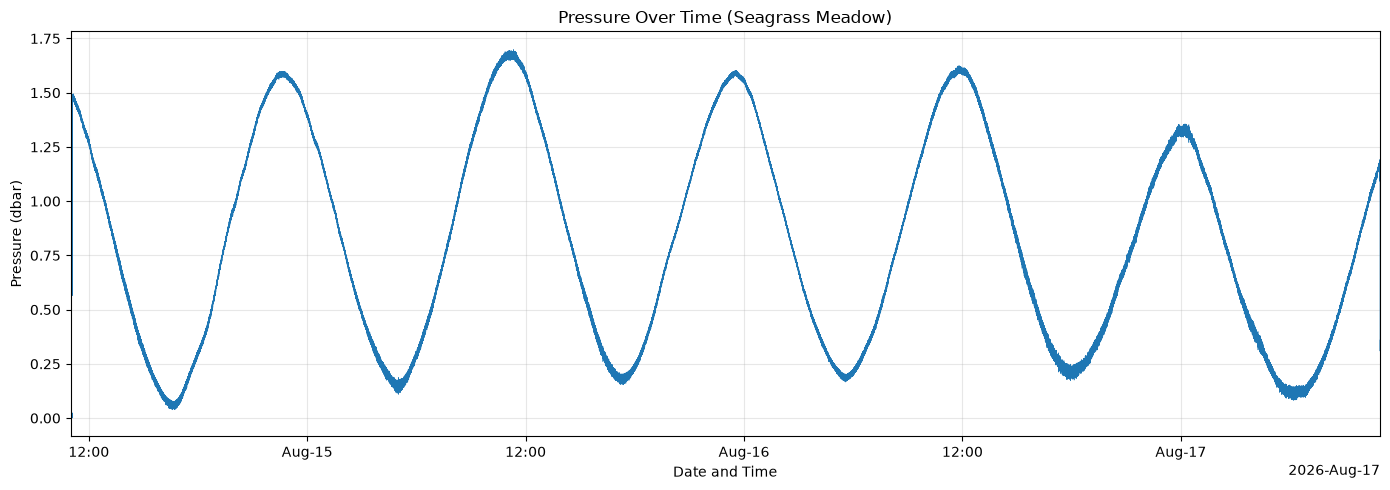

In [68]:
plot_data = data[["Timestamp", "BurstCounter", "Pressure (dbar)"]].copy()
plot_data["Timestamp"] = pd.to_datetime(plot_data["Timestamp"])
plot_data["Pressure (dbar)"] = pd.to_numeric(
    plot_data["Pressure (dbar)"], errors="coerce"
)
plot_data = plot_data.dropna(
    subset=["Timestamp", "Pressure (dbar)"]
).sort_values("Timestamp")

x = mdates.date2num(plot_data["Timestamp"].to_numpy())
y = plot_data["Pressure (dbar)"].to_numpy(dtype=float)

# Leave gaps where sampling pauses between bursts.
burst = plot_data["BurstCounter"]
break_at = np.flatnonzero(burst.ne(burst.shift()).to_numpy()[1:]) + 1
x = np.insert(x, break_at, np.nan)
y = np.insert(y, break_at, np.nan)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, y, linewidth=0.4)

locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

ax.set(
    title="Pressure Over Time (Seagrass Meadow)",
    xlabel="Date and Time",
    ylabel="Pressure (dbar)",
)
ax.grid(True, alpha=0.3)
ax.set_xlim(
    pd.Timestamp("2026-08-14 11:00:00"),
    pd.Timestamp("2026-08-17 10:56:29"),
)
fig.tight_layout()

output_dir = Path("FIGURES")
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / "Pressure_Time_Series.png", dpi=300, bbox_inches="tight")
plt.show()

This is a plot of pressure throughout the 3 day showing the approximately 12 hour tidal cycle from low tide to low tide. This pressure is collected with units of dbar, but dbar is ≈ depth (m). This shows the maximum depth was around 1.7 meters (highest tide) and the minimum depth was around 0.1 meters (lowest tide) for a maximum tidal range approximately 1.6 meters.

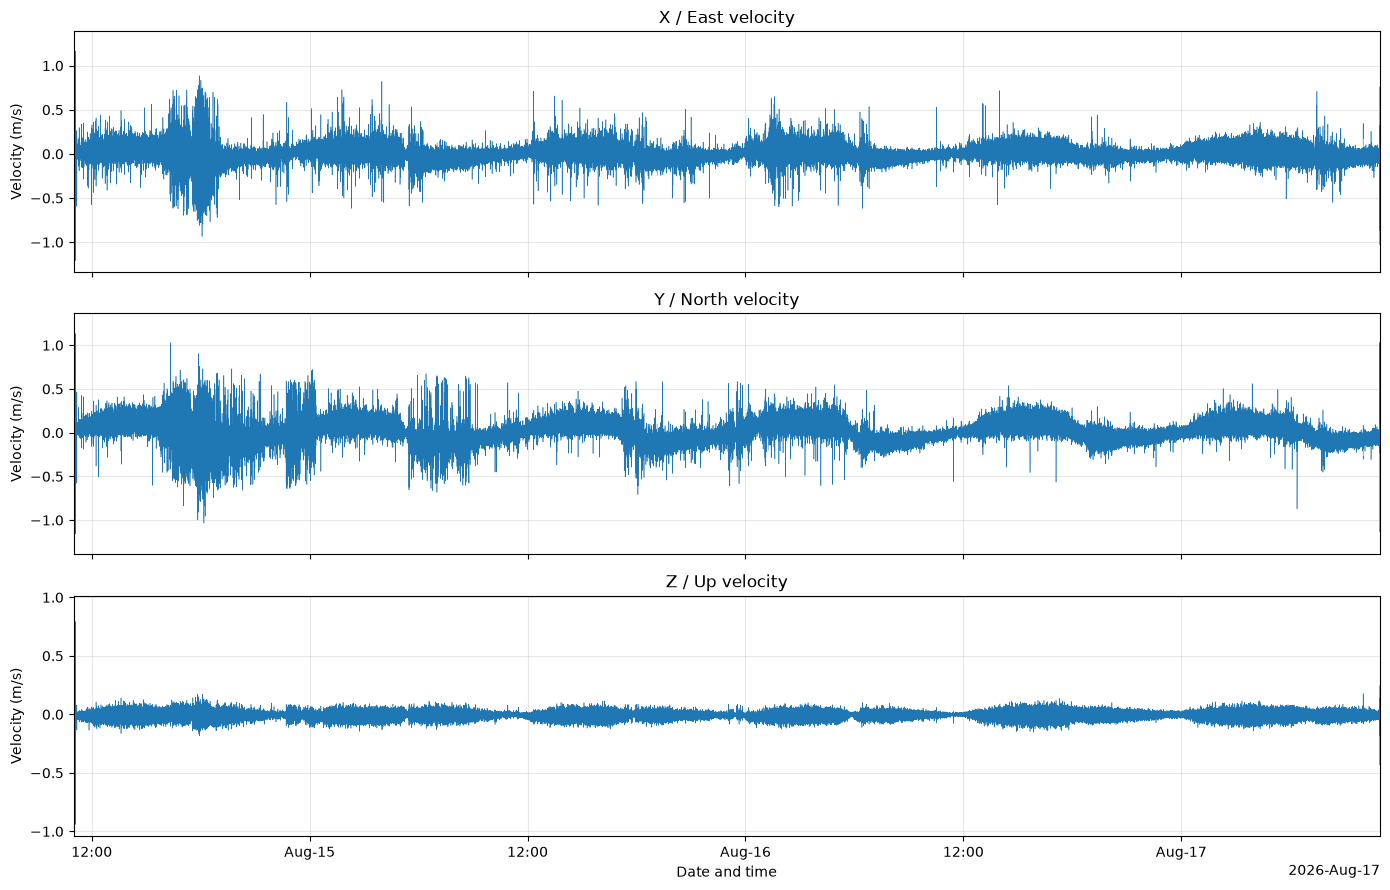

In [67]:
velocity_cols = [
    "Velocity1 (X|East)(m/s)",
    "Velocity2 (Y|North)(m/s)",
    "Velocity3 (Z|Up)(m/s)",
]
titles = ["X / East velocity", "Y / North velocity", "Z / Up velocity"]

plot_data = data[["Timestamp", "BurstCounter", *velocity_cols]].copy()
plot_data["Timestamp"] = pd.to_datetime(plot_data["Timestamp"])

for col in velocity_cols:
    plot_data[col] = pd.to_numeric(plot_data[col], errors="coerce")

plot_data = plot_data.dropna(subset=["Timestamp"]).sort_values("Timestamp")

# Break the plotted lines where a new burst begins.
burst = plot_data["BurstCounter"]
break_at = np.flatnonzero(burst.ne(burst.shift()).to_numpy()[1:]) + 1
x = mdates.date2num(plot_data["Timestamp"].to_numpy())

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, col, title in zip(axes, velocity_cols, titles):
    y = plot_data[col].to_numpy(dtype=float)
    x_plot = np.insert(x, break_at, np.nan)
    y_plot = np.insert(y, break_at, np.nan)

    ax.plot(x_plot, y_plot, linewidth=0.4)
    ax.set_title(title)
    ax.set_ylabel("Velocity (m/s)")
    ax.grid(True, alpha=0.3)

locator = mdates.AutoDateLocator()
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
axes[-1].set_xlabel("Date and time")

axes[0].set_xlim(
    pd.Timestamp("2026-08-14 11:00:00"),
    pd.Timestamp("2026-08-17 10:56:29"),
)

fig.tight_layout()

output_dir = Path("FIGURES")
output_dir.mkdir(exist_ok=True)

fig.savefig(output_dir / "Velocity_Time_Series.png", dpi=300, bbox_inches="tight")
plt.show()

This 3-plot subplot shows the directional velocities for all 3 directions measured by the Nortek ADV (East, North, and Upward). Looking at these velocities they are generally all below 0.5 m/s in both the positive and negative directions, but the amplitudes of the velocities in the east and north directions were greater than that in the upward direction, which did not go too far from 0 m/s throughout the entire sampling period. I need to look into how related this velocities are to the tidal data from the last plot.